# Python Notebook 2: Classification Modelling & Hyperparameter Tuning
## 5DATA002W.2 – Machine Learning & Data Mining
**Author:** Viraj Jayasiri - w2153009  
**Code Peer Reviewer:** Maneth Liyanage  
**Peer Review Date:** 11/03/2026  
**Module:** 5DATA002W.2 – Machine Learning & Data Mining

---
This notebook contains classification modelling for Loan Approval Status prediction using:
- Naïve Bayes (NB)
- Logistic Regression (LR)
- K-Nearest Neighbours (KNN)

It also includes hyperparameter tuning using GridSearchCV for the best-performing model.

## Code Reuse Session 2 – Task: Import Required Libraries for Classification
*(Leveraged and reused from Code Reuse Session 2, Week 5)*

In [ ]:
# Import pandas for loading and manipulating the prepared dataset
import pandas as pd

# Import numpy for numerical array operations
import numpy as np

# Import matplotlib and seaborn for visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Import StandardScaler for feature scaling (required by LR and KNN)
from sklearn.preprocessing import StandardScaler

# Import train_test_split for splitting data into training and test sets
from sklearn.model_selection import train_test_split, GridSearchCV

# Import the three classification algorithms
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Import evaluation metrics for model assessment
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, accuracy_score,
    precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay
)

# Import warnings and suppress non-critical warnings
import warnings
warnings.filterwarnings('ignore')

# Print confirmation
print('All libraries imported successfully.')

All libraries imported successfully.


## Code Reuse Session 2 – Task: Load and Inspect the Classification Dataset
*(Leveraged and reused from Code Reuse Session 2, Week 5)*

In [2]:
# Load Dataset A (prepared in Notebook 1) for classification modelling
df = pd.read_csv('/content/drive/MyDrive/k_ml/dataset_A_classification.csv')

# Display the first 5 rows to verify the dataset is correctly loaded
df.head()

,age,income,home_ownership_enc,emplyment_length,loan_intent_enc,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status
0,40.0,182004,3,3,1,35000,8.00,0.19,0,11,0
1,40.0,90000,0,3,2,35000,12.42,0.39,0,14,0
2,40.0,131004,0,9,5,30000,7.90,0.23,0,13,0
3,40.0,150000,0,9,0,25000,11.89,0.17,0,11,0
4,40.0,132000,0,3,2,25000,16.82,0.22,0,17,0


## Code Reuse Session 2 – Task: Define Features and Target; Check Feature Names and Data Shape
*(Leveraged and reused from Code Reuse Session 2, Week 5)*

In [3]:
# Define the list of input feature columns for classification modelling
feature_names = [
    'age', 'income', 'home_ownership_enc', 'emplyment_length',
    'loan_intent_enc', 'loan_amount', 'loan_interest_rate',
    'loan_income_ratio', 'payment_default_on_file', 'credit_history_length'
]

# Define the target (class) variable
target = 'loan_approval_status'

# Extract features (X) and target (y) arrays from the dataframe
X = df[feature_names]
y = df[target]

# Print the list of all feature names used for building classification models
print('Feature Names used for Classification Modelling:')
print(feature_names)

# Print the data shape (rows, columns)
print('\nData Shape (X):', X.shape)
print('Target Shape (y):', y.shape)
print('\nTarget class distribution (0=Approved, 1=Rejected):')
print(y.value_counts())

Feature Names used for Classification Modelling:
['age', 'income', 'home_ownership_enc', 'emplyment_length', 'loan_intent_enc', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length']

Data Shape (X): (58642, 10)
Target Shape (y): (58642,)

Target class distribution (0=Approved, 1=Rejected):
loan_approval_status
0    50292
1     8350
Name: count, dtype: int64


## Code Reuse Session 2 – Task: Feature Scaling with StandardScaler
*(Leveraged and reused from Code Reuse Session 2, Week 5)*

In [4]:
# Instantiate StandardScaler to normalise features to zero mean and unit variance
scaler = StandardScaler()

# Fit the scaler on X and transform all features
X_scaled = scaler.fit_transform(X)

# Print a confirmation of scaling
print('Feature scaling applied using StandardScaler.')
print('Scaled X shape:', X_scaled.shape)

Feature scaling applied using StandardScaler.
Scaled X shape: (58642, 10)


## Code Reuse Session 2 – Task: Train-Test Split (80/20 with Stratification and Fixed Seed)
*(Leveraged and reused from Code Reuse Session 2, Week 5)*

**Key parameters for reproducibility and fairness:**
- `test_size=0.2` → 80% training, 20% test
- `random_state=42` → ensures all models are evaluated on the **same test instances**
- `stratify=y` → ensures the **Approved:Rejected ratio** is identical in train and test subsets

In [5]:
# Split the scaled data into training (80%) and test (20%) sets
# random_state=42 ensures all models share the same test instances (reproducibility)
# stratify=y ensures the class label ratio is preserved in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Print the sizes of the resulting subsets
print('Training set shape:', X_train.shape)
print('Test set shape:    ', X_test.shape)

# Print the class distribution in training and test sets to confirm stratification
print('\nTraining target distribution (0=Approved, 1=Rejected):')
print(pd.Series(y_train).value_counts())
print('\nTest target distribution (0=Approved, 1=Rejected):')
print(pd.Series(y_test).value_counts())

Training set shape: (46913, 10)
Test set shape:     (11729, 10)

Training target distribution (0=Approved, 1=Rejected):
loan_approval_status
0    40233
1     6680
Name: count, dtype: int64

Test target distribution (0=Approved, 1=Rejected):
loan_approval_status
0    10059
1     1670
Name: count, dtype: int64


## Code Reuse Session 2 – Task: Build Model 1 – Naïve Bayes (NB)
*(Leveraged and reused from Code Reuse Session 2, Week 5)*

In [ ]:
# Instantiate the Gaussian Naïve Bayes classifier
nb = GaussianNB()

# Train the NB model on the training set
nb.fit(X_train, y_train)

# Predict class labels on the test set
y_pred_nb = nb.predict(X_test)

# Predict class probabilities on the test set (needed for AUC-ROC)
y_prob_nb = nb.predict_proba(X_test)[:, 1]

print('Naïve Bayes model trained and predictions generated.')

Naïve Bayes model trained and predictions generated.


## Code Reuse Session 2 – Task: Evaluate Model 1 – Naïve Bayes Confusion Matrix, Report, AUC-ROC
*(Leveraged and reused from Code Reuse Session 2, Week 5)*

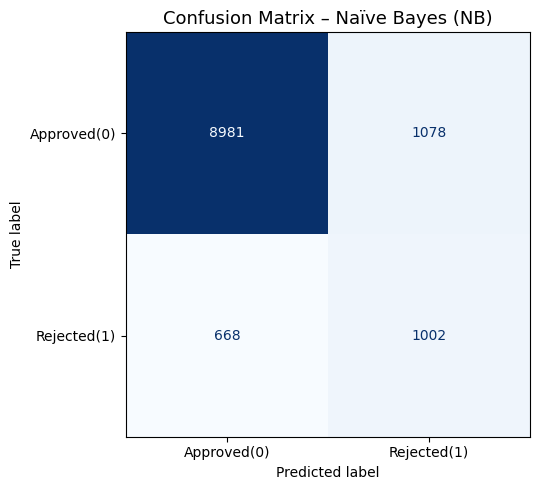

Classification Report – Naïve Bayes (NB):
              precision    recall  f1-score   support

 Approved(0)       0.93      0.89      0.91     10059
 Rejected(1)       0.48      0.60      0.53      1670

    accuracy                           0.85     11729
   macro avg       0.71      0.75      0.72     11729
weighted avg       0.87      0.85      0.86     11729

Accuracy:  0.8511
Precision: 0.4817
Recall:    0.6000
F1-Score:  0.5344
AUC-ROC:   0.8558


In [7]:
# Compute and plot the confusion matrix for NB on the test set
cm_nb = confusion_matrix(y_test, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=['Approved(0)', 'Rejected(1)'])
fig, ax = plt.subplots(figsize=(6, 5))
disp_nb.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix – Naïve Bayes (NB)', fontsize=13)
plt.tight_layout()
plt.show()

# Print full classification report for NB
print('Classification Report – Naïve Bayes (NB):')
print(classification_report(y_test, y_pred_nb,
                             target_names=['Approved(0)', 'Rejected(1)']))

# Calculate and print individual metrics
print(f'Accuracy:  {accuracy_score(y_test, y_pred_nb):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_nb):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_nb):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_nb):.4f}')
print(f'AUC-ROC:   {roc_auc_score(y_test, y_prob_nb):.4f}')

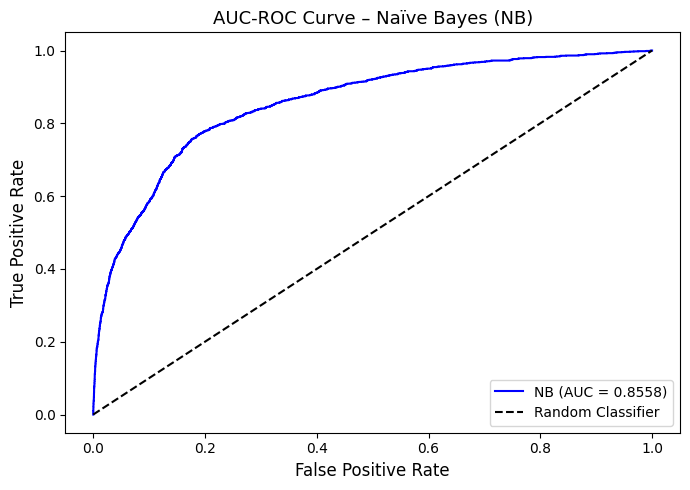

In [8]:
# Plot the AUC-ROC curve for Naïve Bayes
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
auc_nb = roc_auc_score(y_test, y_prob_nb)

plt.figure(figsize=(7, 5))
plt.plot(fpr_nb, tpr_nb, label=f'NB (AUC = {auc_nb:.4f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('AUC-ROC Curve – Naïve Bayes (NB)', fontsize=13)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Code Reuse Session 2 – Task: Build Model 2 – Logistic Regression (LR)
*(Leveraged and reused from Code Reuse Session 2, Week 5)*

In [9]:
# Instantiate the Logistic Regression classifier with max 1000 iterations for convergence
lr = LogisticRegression(max_iter=1000, random_state=42)

# Train the LR model on the training set
lr.fit(X_train, y_train)

# Predict class labels on the test set
y_pred_lr = lr.predict(X_test)

# Predict class probabilities on the test set (needed for AUC-ROC)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print('Logistic Regression model trained and predictions generated.')

Logistic Regression model trained and predictions generated.


## Code Reuse Session 2 – Task: Evaluate Model 2 – Logistic Regression Confusion Matrix, Report, AUC-ROC
*(Leveraged and reused from Code Reuse Session 2, Week 5)*

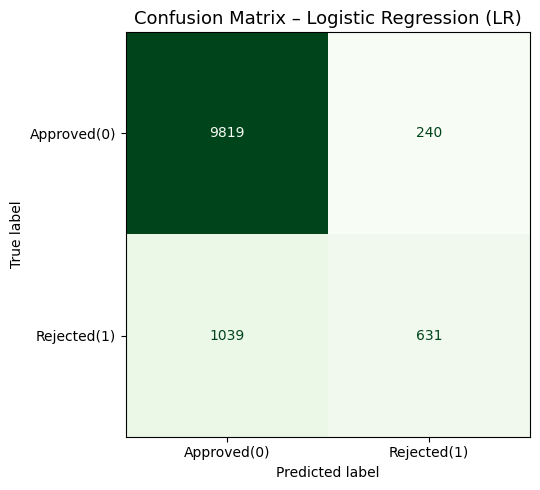

Classification Report – Logistic Regression (LR):
              precision    recall  f1-score   support

 Approved(0)       0.90      0.98      0.94     10059
 Rejected(1)       0.72      0.38      0.50      1670

    accuracy                           0.89     11729
   macro avg       0.81      0.68      0.72     11729
weighted avg       0.88      0.89      0.88     11729

Accuracy:  0.8910
Precision: 0.7245
Recall:    0.3778
F1-Score:  0.4967
AUC-ROC:   0.8730


In [10]:
# Compute and plot the confusion matrix for LR on the test set
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Approved(0)', 'Rejected(1)'])
fig, ax = plt.subplots(figsize=(6, 5))
disp_lr.plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title('Confusion Matrix – Logistic Regression (LR)', fontsize=13)
plt.tight_layout()
plt.show()

# Print full classification report for LR
print('Classification Report – Logistic Regression (LR):')
print(classification_report(y_test, y_pred_lr,
                             target_names=['Approved(0)', 'Rejected(1)']))

print(f'Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_lr):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_lr):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_lr):.4f}')
print(f'AUC-ROC:   {roc_auc_score(y_test, y_prob_lr):.4f}')

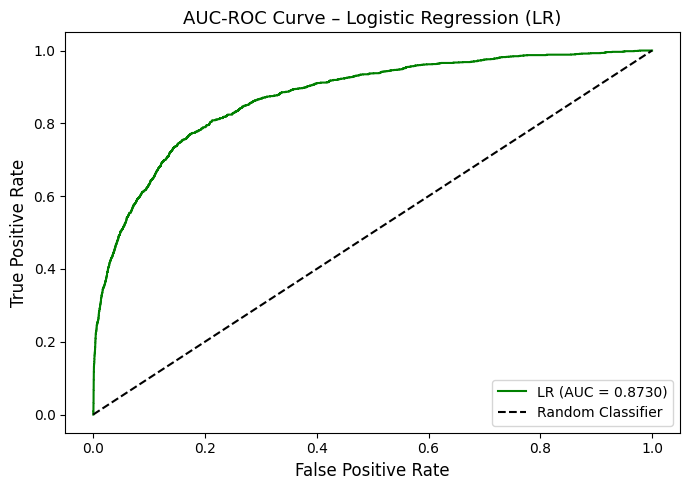

In [11]:
# Plot the AUC-ROC curve for Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, label=f'LR (AUC = {auc_lr:.4f})', color='green')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('AUC-ROC Curve – Logistic Regression (LR)', fontsize=13)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Code Reuse Session 2 – Task: Build Model 3 – K-Nearest Neighbours (KNN, K=5)
*(Leveraged and reused from Code Reuse Session 2, Week 5)*

In [12]:
# Instantiate the KNN classifier with K=5 neighbours
knn = KNeighborsClassifier(n_neighbors=5)

# Train the KNN model on the training set
knn.fit(X_train, y_train)

# Predict class labels on the test set
y_pred_knn = knn.predict(X_test)

# Predict class probabilities on the test set (needed for AUC-ROC)
y_prob_knn = knn.predict_proba(X_test)[:, 1]

print('K-Nearest Neighbours model trained and predictions generated.')

K-Nearest Neighbours model trained and predictions generated.


## Code Reuse Session 2 – Task: Evaluate Model 3 – KNN Confusion Matrix, Report, AUC-ROC
*(Leveraged and reused from Code Reuse Session 2, Week 5)*

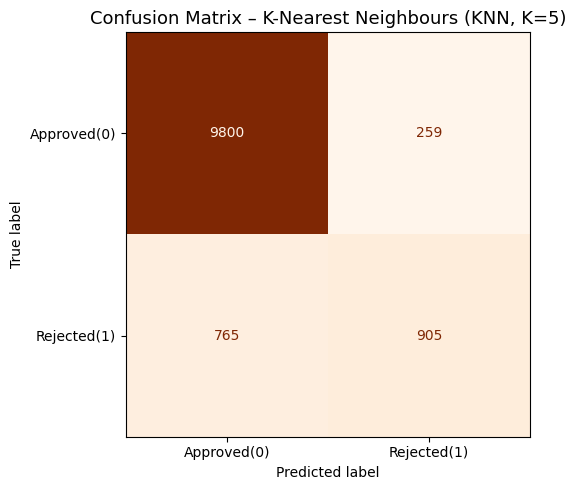

Classification Report – K-Nearest Neighbours (KNN, K=5):
              precision    recall  f1-score   support

 Approved(0)       0.93      0.97      0.95     10059
 Rejected(1)       0.78      0.54      0.64      1670

    accuracy                           0.91     11729
   macro avg       0.85      0.76      0.79     11729
weighted avg       0.91      0.91      0.91     11729

Accuracy:  0.9127
Precision: 0.7775
Recall:    0.5419
F1-Score:  0.6387
AUC-ROC:   0.8545


In [13]:
# Compute and plot the confusion matrix for KNN on the test set
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['Approved(0)', 'Rejected(1)'])
fig, ax = plt.subplots(figsize=(6, 5))
disp_knn.plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title('Confusion Matrix – K-Nearest Neighbours (KNN, K=5)', fontsize=13)
plt.tight_layout()
plt.show()

# Print full classification report for KNN
print('Classification Report – K-Nearest Neighbours (KNN, K=5):')
print(classification_report(y_test, y_pred_knn,
                             target_names=['Approved(0)', 'Rejected(1)']))

print(f'Accuracy:  {accuracy_score(y_test, y_pred_knn):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_knn):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_knn):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_knn):.4f}')
print(f'AUC-ROC:   {roc_auc_score(y_test, y_prob_knn):.4f}')

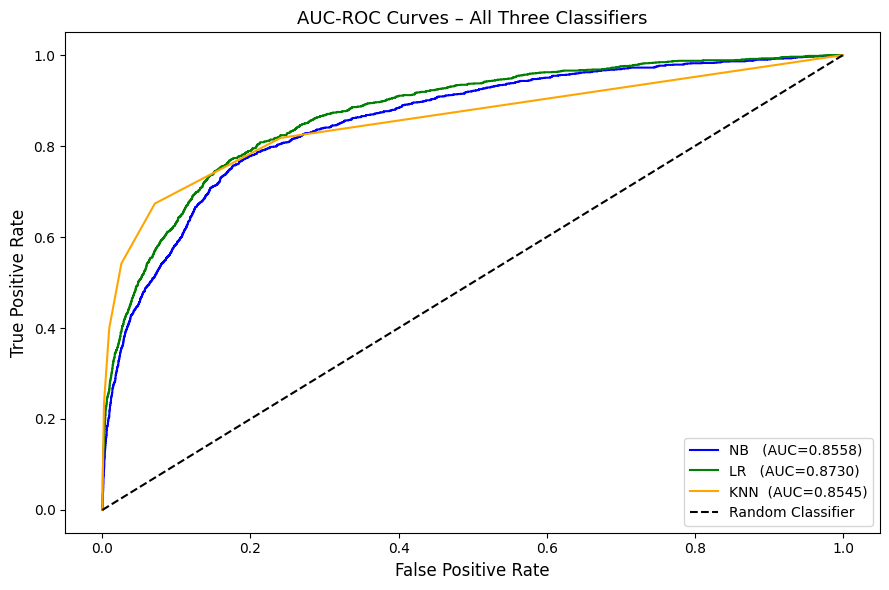

In [14]:
# Plot AUC-ROC curves for all three models on one chart for comparison
plt.figure(figsize=(9, 6))
plt.plot(fpr_nb, tpr_nb, label=f'NB   (AUC={auc_nb:.4f})', color='blue')
plt.plot(fpr_lr, tpr_lr, label=f'LR   (AUC={auc_lr:.4f})', color='green')

# Calculate KNN ROC
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
auc_knn = roc_auc_score(y_test, y_prob_knn)
plt.plot(fpr_knn, tpr_knn, label=f'KNN  (AUC={auc_knn:.4f})', color='orange')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('AUC-ROC Curves – All Three Classifiers', fontsize=13)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Code Reuse Session 2 – Task: Compile All Model Test Scores into Summary Table
*(Leveraged and reused from Code Reuse Session 2, Week 5)*

In [15]:
# Compile all evaluation metric scores for all three models into a summary table
results_summary = pd.DataFrame({
    'Model': ['Naïve Bayes (NB)', 'Logistic Regression (LR)', 'KNN (K=5)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn)
    ],
    'Precision (Rejected)': [
        precision_score(y_test, y_pred_nb),
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_knn)
    ],
    'Recall (Rejected)': [
        recall_score(y_test, y_pred_nb),
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_knn)
    ],
    'F1-Score (Rejected)': [
        f1_score(y_test, y_pred_nb),
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_knn)
    ],
    'AUC-ROC': [auc_nb, auc_lr, auc_knn]
})

# Round values for readability
results_summary = results_summary.round(4)
print('Model Performance Summary (Test Set):')
print(results_summary.to_string(index=False))

Model Performance Summary (Test Set):
                   Model  Accuracy  Precision (Rejected)  Recall (Rejected)  F1-Score (Rejected)  AUC-ROC
        Naïve Bayes (NB)    0.8511                0.4817             0.6000               0.5344   0.8558
Logistic Regression (LR)    0.8910                0.7245             0.3778               0.4967   0.8730
               KNN (K=5)    0.9127                0.7775             0.5419               0.6387   0.8545


## Code Reuse Session 2 – Task: Hyperparameter Tuning – GridSearchCV on Best Model (NB)
*(Leveraged and reused from Code Reuse Session 2, Week 5)*

**Best model selected:** Naïve Bayes (NB) – highest Recall for Rejected class (0.6000), satisfying the success criteria to maximise correctly detected rejected loan applications.

In [16]:
# Define the hyperparameter grid for Naïve Bayes
# var_smoothing controls the portion of the largest variance added to all variances for stability
param_grid_nb = {
    'var_smoothing': np.logspace(-12, 0, 13)
}

# Instantiate GridSearchCV to search for the best var_smoothing value
# cv=5: 5-fold cross-validation on the training set
# scoring='recall': optimise for Recall (success criteria metric for rejected class)
gs_nb = GridSearchCV(
    GaussianNB(),
    param_grid_nb,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

# Fit GridSearchCV on the training data to find optimal hyperparameters
gs_nb.fit(X_train, y_train)

# Print the best hyperparameter values found by GridSearchCV
print('GridSearchCV – Best Hyperparameters for Naïve Bayes:')
print(gs_nb.best_params_)
print(f'Best Cross-Validated Recall Score: {gs_nb.best_score_:.4f}')

GridSearchCV – Best Hyperparameters for Naïve Bayes:
{'var_smoothing': np.float64(1e-12)}
Best Cross-Validated Recall Score: 0.6162


## Code Reuse Session 2 – Task: Evaluate Tuned NB Model on Test Set
*(Leveraged and reused from Code Reuse Session 2, Week 5)*

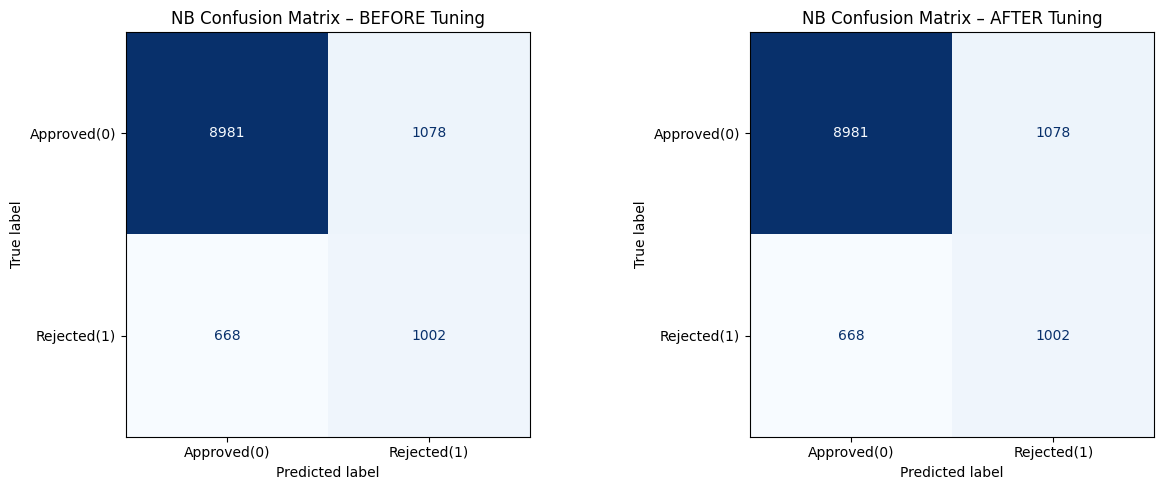

Metrics Comparison – Naïve Bayes Before vs After GridSearchCV Tuning:
Metric                   Before      After
------------------------------------------
Recall (Rejected)        0.6000     0.6000
Precision                0.4817     0.4817
Accuracy                 0.8511     0.8511
AUC-ROC                  0.8558     0.8558


In [17]:
# Extract the best estimator from GridSearchCV
nb_tuned = gs_nb.best_estimator_

# Generate predictions on the test set using the tuned model
y_pred_nb_tuned = nb_tuned.predict(X_test)

# Generate class probabilities for AUC-ROC
y_prob_nb_tuned = nb_tuned.predict_proba(X_test)[:, 1]

# Plot confusion matrix BEFORE tuning
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(cm_nb, display_labels=['Approved(0)', 'Rejected(1)']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('NB Confusion Matrix – BEFORE Tuning', fontsize=12)

cm_nb_tuned = confusion_matrix(y_test, y_pred_nb_tuned)
ConfusionMatrixDisplay(cm_nb_tuned, display_labels=['Approved(0)', 'Rejected(1)']).plot(
    ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('NB Confusion Matrix – AFTER Tuning', fontsize=12)

plt.tight_layout()
plt.show()

# Print metrics before and after tuning
print('Metrics Comparison – Naïve Bayes Before vs After GridSearchCV Tuning:')
print(f"{'Metric':<20} {'Before':>10} {'After':>10}")
print('-' * 42)
print(f"{'Recall (Rejected)':<20} {recall_score(y_test, y_pred_nb):>10.4f} {recall_score(y_test, y_pred_nb_tuned):>10.4f}")
print(f"{'Precision':<20} {precision_score(y_test, y_pred_nb):>10.4f} {precision_score(y_test, y_pred_nb_tuned):>10.4f}")
print(f"{'Accuracy':<20} {accuracy_score(y_test, y_pred_nb):>10.4f} {accuracy_score(y_test, y_pred_nb_tuned):>10.4f}")
print(f"{'AUC-ROC':<20} {roc_auc_score(y_test, y_prob_nb):>10.4f} {roc_auc_score(y_test, y_prob_nb_tuned):>10.4f}")